In [1]:
from ModelClass import RegressionModel
from DatasetClass import Dataset, DatasetMass
from src.helpers import pick_only_target, extract_data
import matplotlib.pyplot as plt
import numpy as np
import itertools
from src.helpers import make_filter_slice
import tensorflow as tf
#import optuna 
#from optuna_dashboard import run_server
import threading


2025-07-07 15:14:35.934014: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-07 15:14:35.946939: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751894075.959755 2279818 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751894075.963633 2279818 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-07 15:14:35.979259: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Available GPUs: []


2025-07-07 15:14:40.031971: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [2]:
plt.rcParams.update({
    # from rootpy
    'lines.linewidth': 1,

    # figure layout
    'figure.figsize': [8.75, 5.92],
    'figure.facecolor': 'white',
    'figure.subplot.bottom': 0.16,
    'figure.subplot.top': 0.93,
    'figure.subplot.left': 0.16,
    'figure.subplot.right': 0.95,

    # axes
    'axes.labelsize': 30,
    'axes.labelpad': 15,

    # ticks
    'xtick.top': True,
    'xtick.labelsize': 19,
    'xtick.major.size': 10,
    'xtick.minor.size': 5,
    'xtick.direction': 'in',
    'xtick.minor.visible': True,
    'ytick.right': True,
    'ytick.labelsize': 19,
    'ytick.major.size': 14,
    'ytick.minor.size': 7,
    'ytick.direction': 'in',
    'ytick.minor.visible': True,
    
    # lines
    'lines.markersize': 8,

    # legend
    'legend.numpoints': 1,
    'legend.fontsize': 18,
    'legend.labelspacing': 0.3,
    'legend.frameon': False,
})

In [3]:
erik_data = "/scratch/ucjf-atlas/htautau/SM_Htautau_R22/V02_skim_mva_01/*/*/*/*/*H125*.root"
patrik_data = "/scratch/ucjf-atlas/htautau/SM_Htautau_R22/V02_skim_mva_01/*/*/*/*/*Ztt*.root"

In [15]:
dataset = DatasetMass(file_paths = patrik_data)
dataset.load_data("data_mmc")
number = 0
# Assuming get_phi_mask is a method, call it with parentheses
phi_mask = dataset.get_phi_mask()
lorentz_mask = dataset.get_lorentz_mask()
number = np.sum(phi_mask)
number_lorentz = np.sum(lorentz_mask)
print(f"Number of events with phi mass: {number}")
print(f"Number of events with lorentz mask: {number_lorentz}")


Number of events with phi mass: 7
Number of events with lorentz mask: 24


2025-06-22 23:05:18.265275: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


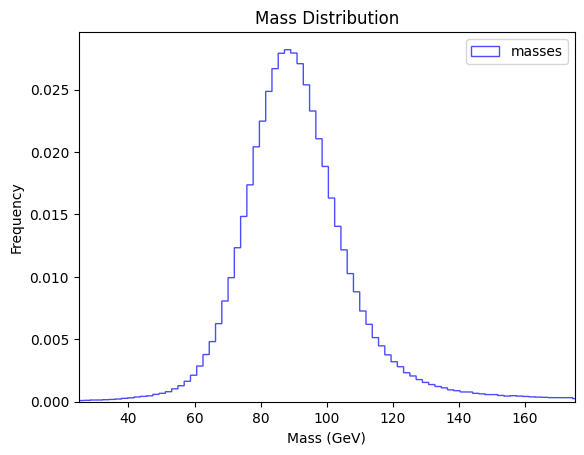

In [5]:
@tf.function
def pick_only_mmc(data, label):
    return data[-1]

masses = np.array(extract_data(dataset.val_dataset.map(pick_only_mmc)))


plt.hist(masses, bins=1000, histtype='step', label='masses', density=True, color='blue', alpha=0.7)
plt.xlabel('Mass (GeV)')
plt.ylabel('Frequency')
plt.xlim(25, 175)
plt.title('Mass Distribution')
plt.legend()
plt.show()  


In [6]:
masses_array = []
for features, masses in dataset.train_dataset.batch(1000000):
    masses_array.append(masses.numpy())

2025-06-30 23:59:15.230206: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


96.872536


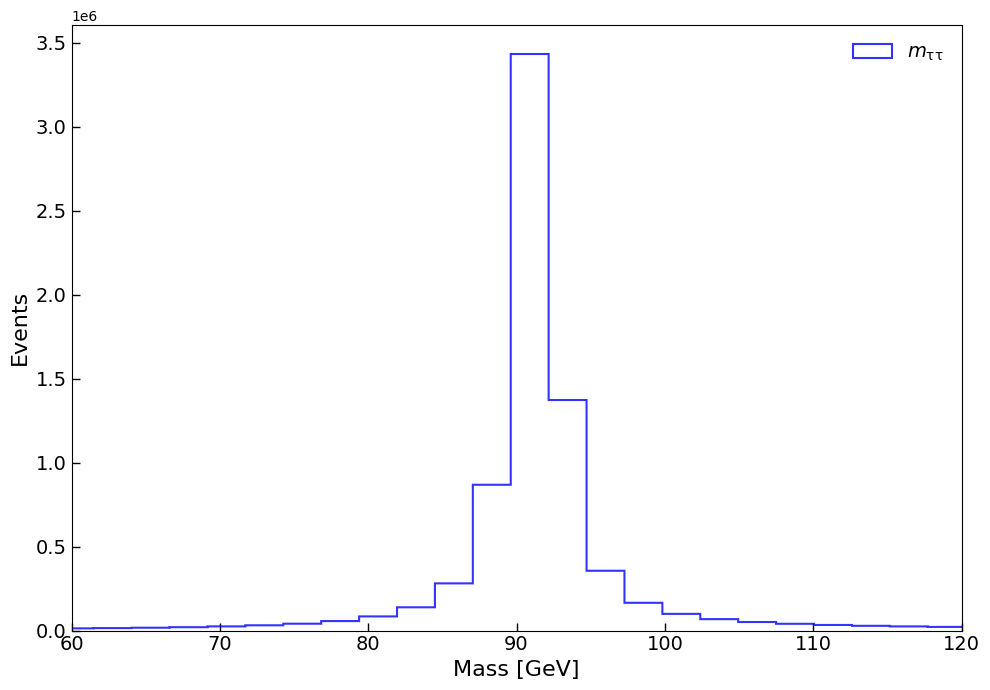

In [10]:
print(np.mean(np.concatenate(masses_array, axis=0)))

plt.figure(figsize=(10, 7))
plt.hist(np.concatenate(masses_array, axis=0), bins=1000, histtype='step', 
         label=r'$m_{\mathrm{\tau\tau}}$', density=False, color='blue', alpha=0.8, linewidth=1.5)

plt.xlabel(r'Mass [GeV]', fontsize=16)
plt.ylabel(r'Events', fontsize=16)
plt.xlim(60, 120)
#plt.title(r'Mass Distribution', fontsize=18, weight='bold')
plt.legend(fontsize=14, loc='upper right', frameon=False)
#plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6, width=1)
plt.tight_layout()
plt.show()



Mean of the distribution: 96.87 GeV
Peak Location: 91.33 GeV
Peak Height (Number of entries): 2147585.00
FWHM Height (Number of entries): 1075212.50
Full Width at Half Maximum (FWHM): 3.06 GeV
number of entries in the peak: 7799005


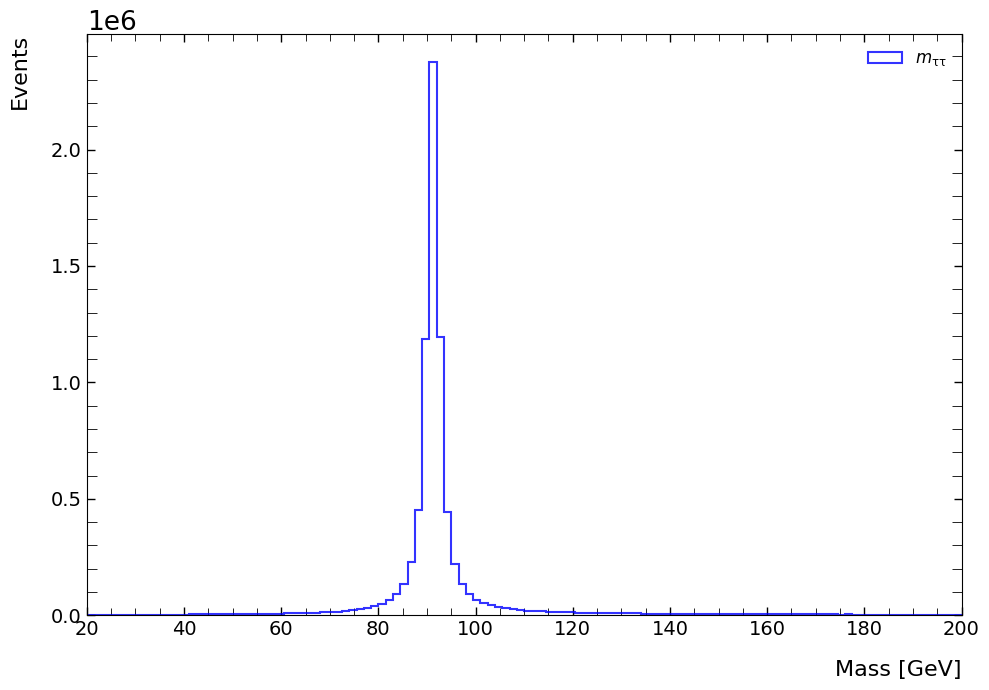

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_widths

# Concatenate the mass arrays as in the user's code
concatenated_masses = np.concatenate(masses_array, axis=0)

# Generate the histogram data
counts, bin_edges = np.histogram(concatenated_masses, bins=120, range=(20, 180))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_centers[1] - bin_centers[0]

# --- Find the Peak and FWHM (Calculation remains the same) ---

# Find the most prominent peak in the histogram data
peaks, _ = find_peaks(counts, prominence=(np.max(counts)/2))

# Get the location of the most prominent peak
peak_location = bin_centers[peaks[0]]
peak_height = counts[peaks[0]]

# Calculate the width at half the peak's height (FWHM)
# The output contains: [0] widths, [1] width_heights, [2] left_ips, [3] right_ips
results_fwhm = peak_widths(counts, peaks, rel_height=0.5)

# Extract FWHM and its properties for the main peak
fwhm_in_bins = results_fwhm[0][0]
fwhm_in_gev = fwhm_in_bins * bin_width
fwhm_height = results_fwhm[1][0] # The y-value where the width is measured
fwhm_left_x_bin = results_fwhm[2][0] # x-value of the left intercept in bins
fwhm_right_x_bin = results_fwhm[3][0] # x-value of the right intercept in bins

# Convert the FWHM x-intercepts from bins to GeV
fwhm_left_x_gev = bin_centers[0] + fwhm_left_x_bin * bin_width
fwhm_right_x_gev = bin_centers[0] + fwhm_right_x_bin * bin_width

# --- Output the results ---
print(f"Mean of the distribution: {np.mean(concatenated_masses):.2f} GeV")
print(f"Peak Location: {peak_location:.2f} GeV")
print(f"Peak Height (Number of entries): {peak_height:.2f}")
print(f"FWHM Height (Number of entries): {fwhm_height:.2f}")
print(f"Full Width at Half Maximum (FWHM): {fwhm_in_gev:.2f} GeV")
print(f"number of entries in the peak: {len(concatenated_masses)}")

# --- CORRECTED Plotting with annotations ---
plt.figure(figsize=(10, 7))
plt.hist(concatenated_masses, bins=120, range=(20, 200), histtype='step',
         label=r'$m_{\mathrm{\tau\tau}}$', density=False, color='blue', alpha=0.8, linewidth=1.5)

# Plot the peak location
#plt.axvline(peak_location, color='red', linestyle='--', label=f'Peak at {peak_location:.2f} GeV')

# Plot the FWHM line using the precise coordinates from peak_widths
#plt.plot([fwhm_left_x_gev, fwhm_right_x_gev], [fwhm_height, fwhm_height], 'g|-',
#         markersize=10, label=f'FWHM = {fwhm_in_gev:.2f} GeV')

plt.xlabel(r'Mass [GeV]', fontsize=16, horizontalalignment='right', x=1)
plt.ylabel(r'Events', fontsize=16, horizontalalignment='right', y=1)
plt.xlim(20, 200)
plt.legend(fontsize=12, loc='upper right')
plt.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6, width=1)
#plt.grid(True, linestyle='--', alpha=0.6)
#plt.title('Mass Distribution with Corrected FWHM', fontsize=18)
plt.savefig('mass_distribution_Ztt_without_fwhm.png', dpi=300)
plt.tight_layout()
plt.show()

In [8]:
def make_slices(n_slices=10):
        bins = np.linspace(20, 200.0, num=n_slices+1)
        functions = [make_filter_slice(lb, ub) for lb, ub in zip(bins[:-1], bins[1:])]
        n_slices = [dataset.train_dataset.filter(functions[i]) for i in range(n_slices)]

        return n_slices
n_slices = make_slices(100)

#self.make_slices(n_slices)
lorentz_mask = tf.constant(dataset.get_lorentz_mask())
lorentz_indices = tf.squeeze(tf.where(lorentz_mask), axis=1) # [0 1 2 3 4 5 6 7 13 14 ...] 
n_vectors = tf.shape(lorentz_indices)[0] // 4 # number of 4-vectors
lorentz_indices_4d = tf.reshape(lorentz_indices, (n_vectors, 4))  # [n_vectors, 4]

@tf.function
def augment_lorentz(data, target):
    beta = tf.random.uniform(shape = (), minval=-0.98, maxval=0.98) # Shape ()
    #tf.print("used beta: ", beta)
    gamma = 1.0 / tf.sqrt(1.0 - beta**2) # Shape ()
    #tf.print("used gamma: ", gamma)
    
    for i in range(n_vectors):
        vec_indices = lorentz_indices_4d[i] # Shape (4,)
        pt = data[vec_indices[0]] # scalar values
        eta = data[vec_indices[1]]
        #tf.print("eta: ", eta)
        phi = data[vec_indices[2]]
        E = data[vec_indices[3]]
        #tf.print("E: ", E)
        #print(E.shape)
        
        # Convert to Cartesian coordinates
        #px = pt * tf.cos(phi)
        #py = pt * tf.sin(phi)
        pz = pt * tf.sinh(eta) # Shape ()
        #tf.print("pz: ", pz)

        E_prime = gamma * (E - beta * pz) # Shape ()
        #tf.print("E_prime: ", E_prime)
        pz_prime = gamma * (pz - beta * E) 
        
        epsilon = 1e-8
        eta_prime = tf.asinh(pz_prime / (pt + epsilon)) # Shape ()
        #tf.print("eta_prime: ", eta_prime)
        update_indices = tf.reshape(vec_indices, [-1, 1])  # Shape (4, 1)
        update_values = tf.stack([pt, eta_prime, phi, E_prime]) # Shape (4,)
        # Update the tensor
        data = tf.tensor_scatter_nd_update(
            data,
            indices=update_indices,
            updates=update_values
        )
        #print(data.shape)
        
    return data, target
k = 20000  # or self.train_events
slices_cached = [s.cache().repeat() for s in n_slices]
new_dataset = tf.data.Dataset.sample_from_datasets(slices_cached, weights=[1.] * len(slices_cached))
augmented_dataset = new_dataset.map(augment_lorentz, num_parallel_calls=tf.data.AUTOTUNE).take(k)

In [6]:
# d) Now, apply the fastest 'reduce' method from the previous answer.
#    First, isolate the data you want to extract.
masses_only_ds = augmented_dataset.map(lambda features, masses: masses, 
                                       num_parallel_calls=tf.data.AUTOTUNE)

#    Define the initial state and reduction function.
mass_spec = masses_only_ds.element_spec
initial_state = tf.zeros(shape=(0,), dtype=mass_spec.dtype)
def reduce_func(state, batch):
    return tf.concat([state, batch], axis=0)

#    Build the final pipeline and execute the reduction.
final_masses_tensor = (
    masses_only_ds
    .batch(1000)
    .prefetch(tf.data.AUTOTUNE)
    .reduce(initial_state, reduce_func)
)

# e) Get the final result with a single .numpy() call.
masses_array = final_masses_tensor.numpy()
print(f"Shape of final array: {masses_array.shape}")

# Let's check the distribution to prove the sampling worked
unique, counts = np.unique(masses_array, return_counts=True)
print("Distribution of masses in the final array (should be roughly equal):")
print(dict(zip(unique, counts)))

: 

In [9]:
from tqdm import tqdm

masses_array = []

# If you know the number of total events and batch size:
total_events = 20000  # for example, 100 batches
batch_size = 1000
total_batches = total_events // batch_size

for features, masses in tqdm(augmented_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE), total=total_batches, desc="Processing batches"):
    masses_array.append(masses)


Processing batches:   0%|          | 0/20 [00:00<?, ?it/s]

Processing batches: 100%|██████████| 20/20 [12:44<00:00, 37.31s/it]2025-07-01 00:13:20.703478: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-07-01 00:13:20.704271: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-07-01 00:13:20.704835: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] 

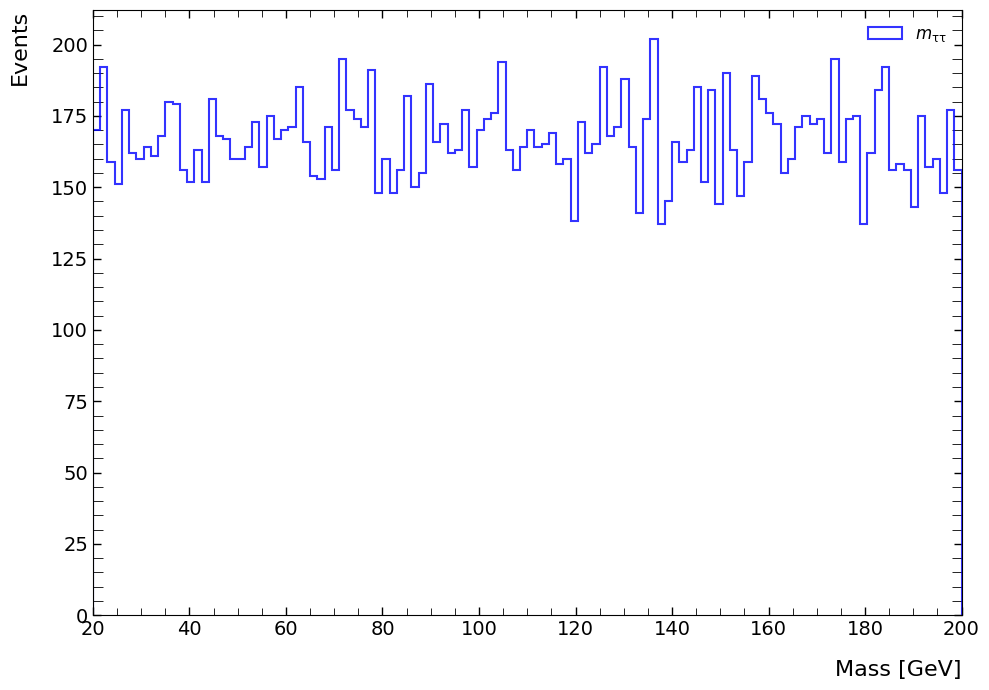

In [10]:
plt.figure(figsize=(10, 7))

plt.hist(np.concatenate(masses_array, axis = 0), bins=120, range=(20, 200), histtype='step',
         label=r'$m_{\mathrm{\tau\tau}}$', density=False, color='blue', alpha=0.8, linewidth=1.5)
#plt.xticks(ticks, fontsize=14, color='red')
plt.xlabel(r'Mass [GeV]', fontsize=16, horizontalalignment='right', x=1)
plt.ylabel(r'Events', fontsize=16, horizontalalignment='right', y=1)
plt.xlim(20, 200)
plt.legend(fontsize=12, loc='upper right')
plt.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6, width=1)
#plt.grid(True, linestyle='--', alpha=0.6)
#plt.title('Mass Distribution with Corrected FWHM', fontsize=18)
plt.savefig('mass_distribution_augmented.png', dpi=300)
plt.tight_layout()
plt.show()